Pearson Correlation (r): 0.6222198269181353
P-value: 6.939468343300088e-09
                            OLS Regression Results                            
Dep. Variable:        HeartAttackRate   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     43.59
Date:                Sun, 27 Apr 2025   Prob (F-statistic):           6.94e-09
Time:                        19:28:45   Log-Likelihood:                -233.84
No. Observations:                  71   AIC:                             471.7
Df Residuals:                      69   BIC:                             476.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

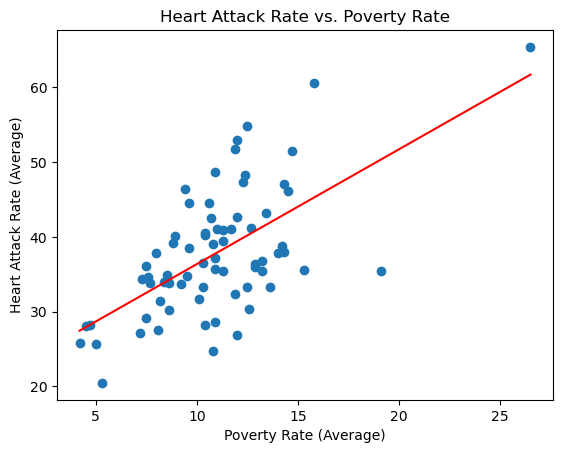

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

#########################################################################################
#########                        Grabbing Data from CSVs                        #########
#########################################################################################
HA_rates_df = pd.read_csv('HA_rates_2000_2021.csv')
povert_rates_df   = pd.read_csv('poverty_rates.csv')

#########################################################################################
#########                             Cleaning Data                             #########
#########################################################################################
HA_rates_df['Value'] = pd.to_numeric(HA_rates_df['Value'], errors='coerce')
povert_rates_df['Value']   = pd.to_numeric(povert_rates_df['Value'],   errors='coerce')

HA_rates_df.dropna(subset=['Value'], inplace=True)
povert_rates_df.dropna(subset=['Value'],   inplace=True)

HA_rates_df.rename(columns={'Value': 'HeartAttackRate'}, inplace=True)
povert_rates_df.rename(columns={'Value': 'PovertyRate'},        inplace=True)


#########################################################################################
#########                      Averaging Thoughout Years                        #########
#########################################################################################
heart_by_county = HA_rates_df.groupby('County', as_index=False)['HeartAttackRate'].mean()
pov_by_county   = povert_rates_df.groupby('County',  as_index=False)['PovertyRate'].mean()


#########################################################################################
#########                          Merging on County                            #########
#########################################################################################
merged_df = pd.merge(heart_by_county, pov_by_county, on='County', how='inner')



#########################################################################################
#########                                 STATS                                 #########
#########################################################################################
pearson_r, p_val = stats.pearsonr(merged_df['PovertyRate'], merged_df['HeartAttackRate'])
print("Pearson Correlation (r):", pearson_r)
print("P-value:", p_val)

# LINEAR REGRESSION
#    Independent variable: Poverty Rate
#    Dependent variable: Heart Attack Rate
X = merged_df['PovertyRate']
y = merged_df['HeartAttackRate']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())  


#########################################################################################
#########                             Plotting Data                             #########
#########################################################################################
plt.scatter(merged_df['PovertyRate'], merged_df['HeartAttackRate'])
plt.xlabel('Poverty Rate (Average)')
plt.ylabel('Heart Attack Rate (Average)')
plt.title('Heart Attack Rate vs. Poverty Rate')


x_vals = np.linspace(merged_df['PovertyRate'].min(), merged_df['PovertyRate'].max(), 100)
x_vals_const = sm.add_constant(x_vals)
y_vals = model.predict(x_vals_const)
plt.plot(x_vals, y_vals, color='red')  

plt.show()


Pearson Correlation (r): -0.5514024690853921
P-value: 6.244308347961147e-07
                            OLS Regression Results                            
Dep. Variable:        HeartAttackRate   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     30.14
Date:                Sun, 27 Apr 2025   Prob (F-statistic):           6.24e-07
Time:                        19:28:45   Log-Likelihood:                -239.23
No. Observations:                  71   AIC:                             482.5
Df Residuals:                      69   BIC:                             487.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

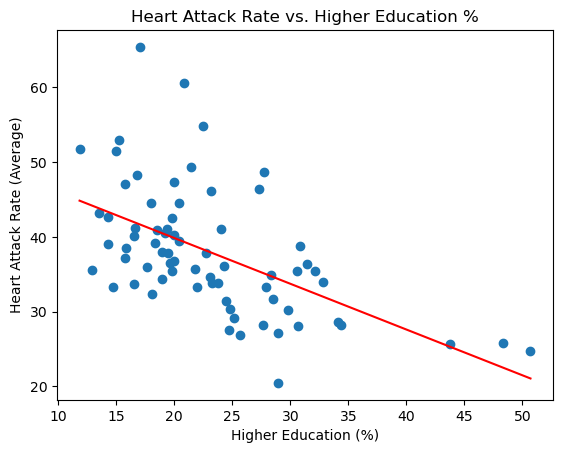

In [3]:
#########################################################################################
#########                        Grabbing Data from CSVs                        #########
#########################################################################################
heart_df = pd.read_csv('HA_rates_2000_2021.csv')
edu_df   = pd.read_csv('higher_education_2017_2019.csv')


#########################################################################################
#########                             Cleaning Data                             #########
#########################################################################################
heart_df['Value'] = pd.to_numeric(heart_df['Value'], errors='coerce')
heart_df['Year'] = pd.to_numeric(heart_df['Year'], errors='coerce')

heart_df.dropna(subset=['Value'], inplace=True)
edu_df.dropna(subset=['Percent'], inplace=True)


heart_df = heart_df[(heart_df['Year'] >= 2017) & (heart_df['Year'] <= 2019)]
edu_df = edu_df[(edu_df['Year'] >= 2017) & (edu_df['Year'] <= 2019)]


heart_df.rename(columns={'Value': 'HeartAttackRate'}, inplace=True)
edu_df.rename(columns={'Percent': 'BachelorsRate'}, inplace=True)

edu_df['County'] = edu_df['County'].str.replace(' County, WI', '')


#########################################################################################
#########                      Averaging Data by County                        #########
#########################################################################################
heart_by_county = heart_by_county.groupby('County', as_index=False)['HeartAttackRate'].mean()
edu_by_county = edu_df.groupby('County', as_index=False)['BachelorsRate'].mean()




#########################################################################################
#########                          Merging on County                            #########
#########################################################################################
merged_df = pd.merge(heart_by_county, edu_by_county, on='County', how='inner')

#########################################################################################
#########                                 STATS                                 #########
#########################################################################################
pearson_r, p_val = stats.pearsonr(merged_df['BachelorsRate'], merged_df['HeartAttackRate'])
print("Pearson Correlation (r):", pearson_r)
print("P-value:", p_val)

# LINEAR REGRESSION
#    Independent variable: Bachelor's Degree Rate
#    Dependent variable: Heart Attack Rate
X = merged_df['BachelorsRate']
y = merged_df['HeartAttackRate']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())  

#########################################################################################
#########                             Plotting Data                             #########
#########################################################################################
plt.scatter(merged_df['BachelorsRate'], merged_df['HeartAttackRate'])
plt.xlabel("Higher Education (%)")
plt.ylabel("Heart Attack Rate (Average)")
plt.title("Heart Attack Rate vs. Higher Education %")

x_vals = np.linspace(merged_df['BachelorsRate'].min(), merged_df['BachelorsRate'].max(), 100)
x_vals_const = sm.add_constant(x_vals)
y_vals = model.predict(x_vals_const)
plt.plot(x_vals, y_vals, color='red')  

plt.show()

Pearson Correlation (r): -0.3509642363963629
P-value: 0.0025053904857547356
                            OLS Regression Results                            
Dep. Variable:        HeartAttackRate   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     9.834
Date:                Sun, 27 Apr 2025   Prob (F-statistic):            0.00251
Time:                        19:28:46   Log-Likelihood:                -262.26
No. Observations:                  72   AIC:                             528.5
Df Residuals:                      70   BIC:                             533.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

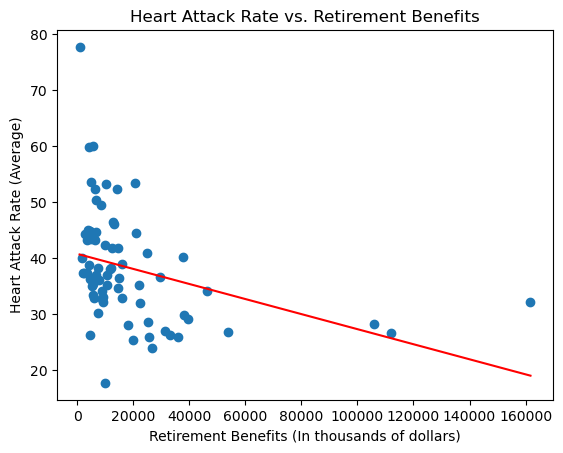

In [4]:
#########################################################################################
#########                        Grabbing Data from CSVs                        #########
#########################################################################################
heart_df = pd.read_csv('HA_rates_2000_2021.csv')
benefits_df = pd.read_csv('retirement_benefits_2017_2019.csv')


#########################################################################################
#########                             Cleaning Data                             #########
#########################################################################################
heart_df['Value'] = pd.to_numeric(heart_df['Value'], errors='coerce')
heart_df['Year'] = pd.to_numeric(heart_df['Year'], errors='coerce')


heart_df.dropna(subset=['Value'], inplace=True)
benefits_df.dropna(subset=['Retirement_Benefits'], inplace=True)


heart_df = heart_df[(heart_df['Year'] >= 2017) & (heart_df['Year'] <= 2019)]
benefits_df = benefits_df[(benefits_df['Year'] >= 2017) & (benefits_df['Year'] <= 2019)]


heart_df.rename(columns={'Value': 'HeartAttackRate'}, inplace=True)


benefits_df = benefits_df[benefits_df['County'] != "Total, Wisconsin"]


#########################################################################################
#########                      Averaging Data by County                        #########
#########################################################################################
heart_by_county = heart_df.groupby('County', as_index=False)['HeartAttackRate'].mean()
benefits_by_county = benefits_df.groupby('County', as_index=False)['Retirement_Benefits'].mean()


#########################################################################################
#########                          Merging on County                            #########
#########################################################################################
merged_df = pd.merge(heart_by_county, benefits_by_county, on='County', how='inner')


#########################################################################################
#########                                 STATS                                 #########
#########################################################################################
pearson_r, p_val = stats.pearsonr(merged_df['Retirement_Benefits'], merged_df['HeartAttackRate'])
print("Pearson Correlation (r):", pearson_r)
print("P-value:", p_val)

# LINEAR REGRESSION
#    Independent variable: Retirement Benefits
#    Dependent variable: Heart Attack Rate
X = merged_df['Retirement_Benefits']
y = merged_df['HeartAttackRate']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())  

#########################################################################################
#########                             Plotting Data                             #########
#########################################################################################
plt.scatter(merged_df['Retirement_Benefits'], merged_df['HeartAttackRate'])
plt.xlabel("Retirement Benefits (In thousands of dollars)")
plt.ylabel("Heart Attack Rate (Average)")
plt.title("Heart Attack Rate vs. Retirement Benefits")

x_vals = np.linspace(merged_df['Retirement_Benefits'].min(), merged_df['Retirement_Benefits'].max(), 100)
x_vals_const = sm.add_constant(x_vals)
y_vals = model.predict(x_vals_const)
plt.plot(x_vals, y_vals, color='red')

plt.show()